In [72]:
import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import spotipy 
from spotipy.oauth2 import SpotifyClientCredentials
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import euclidean

In [17]:
def load_credentials():
    credspath = '../spotify_credentials.txt'
    with open(credspath) as f:
        lines = f.readlines()
        client_id = lines[0].strip().split(' ')[1]
        client_secret = lines[1].strip().split(' ')[1]
    return client_id, client_secret

client_id, client_secret = load_credentials()
client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

In [3]:
section_features = ['duration', 'confidence', 'loudness', 'tempo', 'tempo_confidence', 'key', 'key_confidence', 'mode', 'mode_confidence', 'time_signature', 'time_signature_confidence']

In [4]:
annotated_songs = []
all_songs = []

In [78]:
data_dir = '../song_data/'
song_data = []
for file in os.listdir(data_dir):
    with open(data_dir + file) as f:
        data = json.load(f)
        if 'scene' in data['sections'][0].keys():
            annotated_songs.append(data)
        all_songs.append(data)

In [6]:
len(annotated_songs)/len(all_songs)

0.6571428571428571

In [7]:
section_df = []
for song in song_data:
    for section in song['sections']:
        section_df.append({k: section[k] for k in section_features})

section_df = pd.DataFrame(section_df)

In [21]:
songfiles = glob('../song_data/*.json')
for songfile in songfiles:
    with open(songfile) as f:
        song = json.load(f)
        if 'name' not in song['track']:
            songid = songfile.split('/')[-1].split('.')[0]
            track = sp.track(songid)
            name = track['name']
            artist = track['artists'][0]['name']
            song['track']['name'] = name
            song['track']['artist'] = artist
            # save the updated song data
            with open(songfile, 'w') as f:
                json.dump(song, f)
            

In [22]:
songfiles = glob('../song_data/*.json')
for songfile in songfiles:
    with open(songfile) as f:
        song = json.load(f)
        if 'artists' not in song['track']:
            songid = songfile.split('/')[-1].split('.')[0]
            track = sp.track(songid)
            name = track['name']
            artist = track['artists'][0]['name']
            song['track']['name'] = name
            song['track']['artists'] = artist
            del song['track']['artist']
            # save the updated song data
            with open(songfile, 'w') as f:
                json.dump(song, f)

In [26]:
songfiles = glob('../song_data/*.json')
for songfile in songfiles:
    with open(songfile) as f:
        song = json.load(f)
    songid = songfile.split('/')[-1].split('.')[0]
    track = sp.track(songid)
    artists = [artist['name'] for artist in track['artists']]
    # join artists into one string
    artists = ', '.join(artists)
    song['track']['artists'] = artists
    # save the updated song data
    with open(songfile, 'w') as f:
        json.dump(song, f)

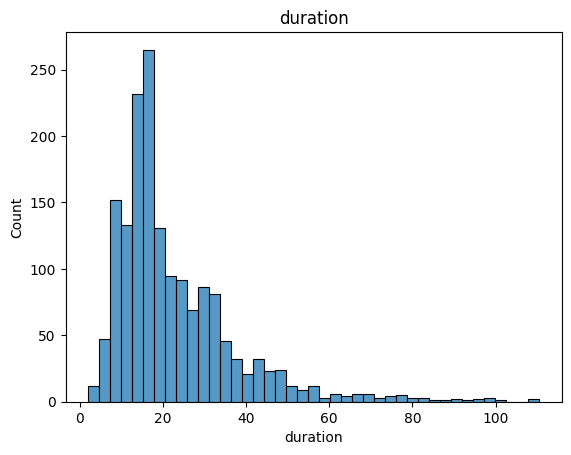

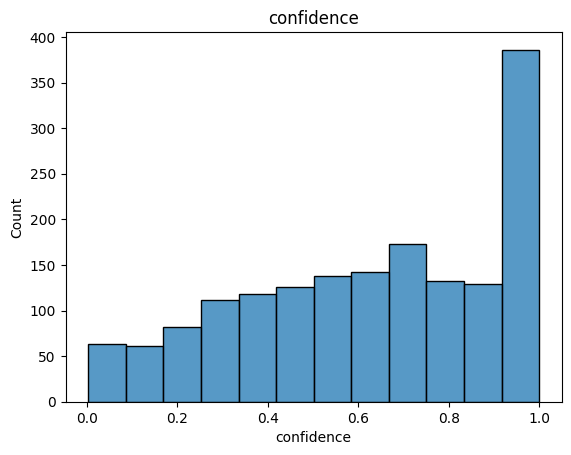

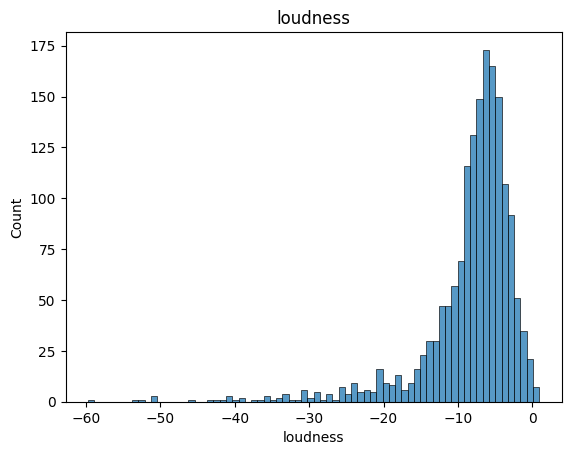

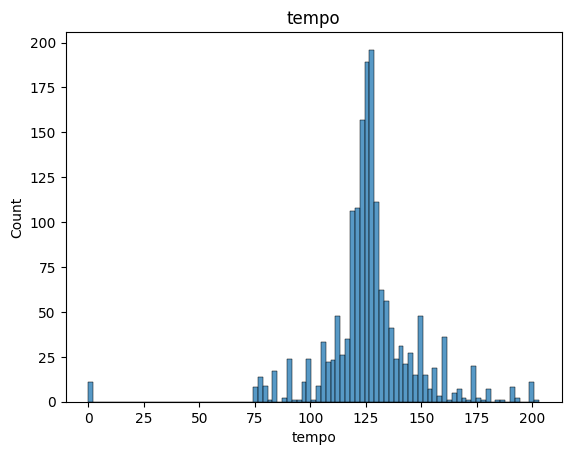

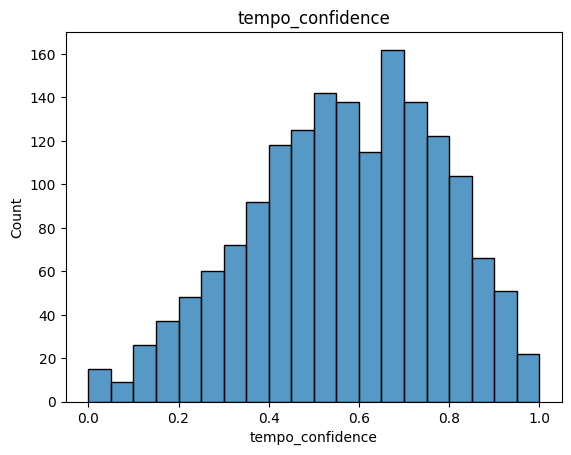

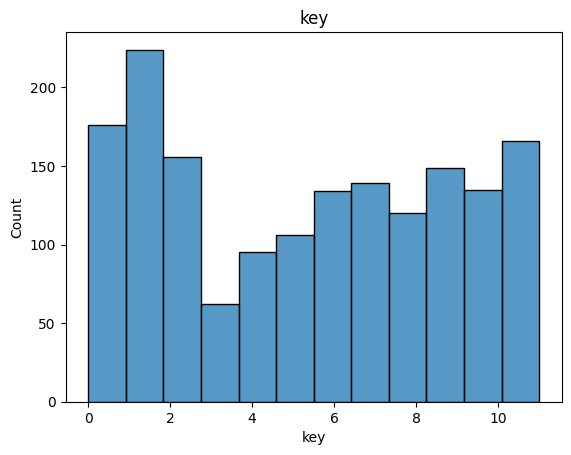

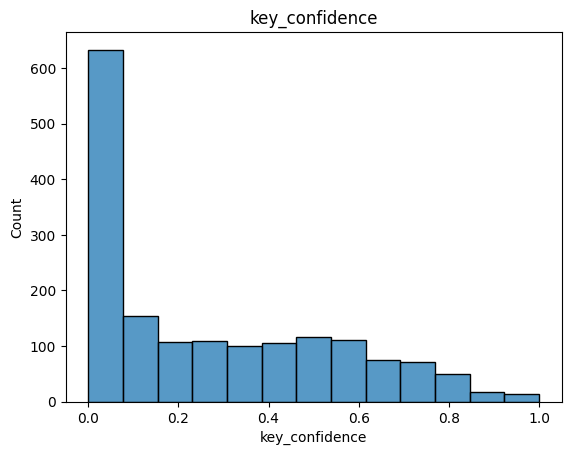

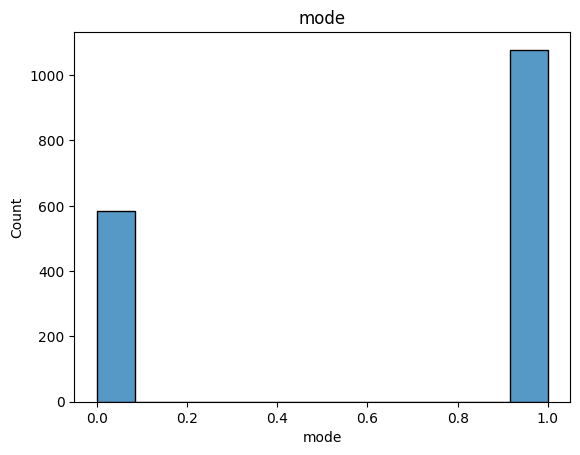

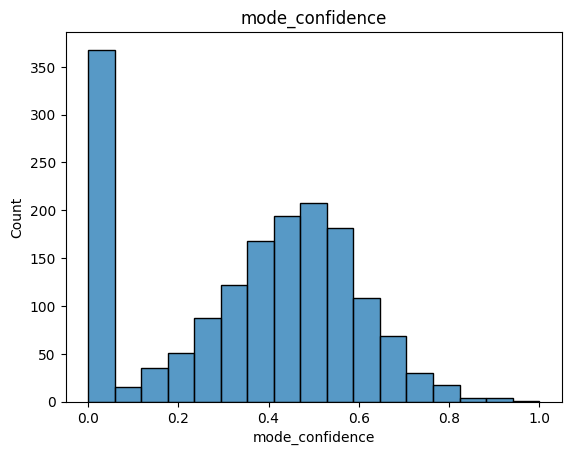

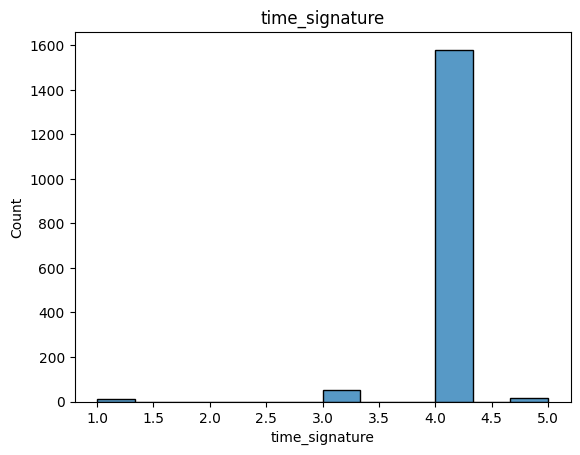

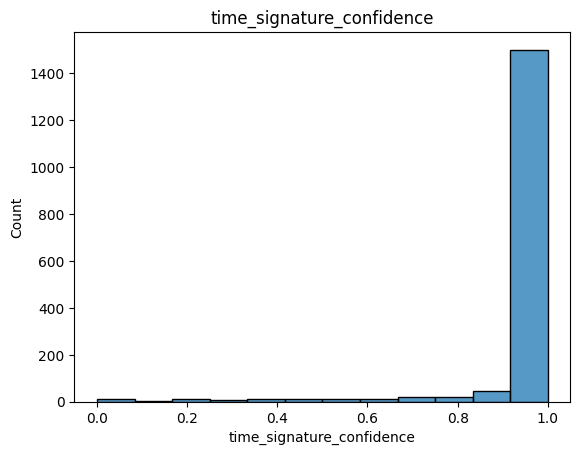

In [27]:
# plot histograms of the features
for feature in section_features:
    plt.figure()
    sns.histplot(section_df[feature])
    plt.title(feature)

In [28]:
features = ['duration', 'confidence', 'loudness', 'tempo', 'tempo_confidence', 'key', 'key_confidence', 'mode', 'mode_confidence']

In [30]:
song_data[0].keys()

dict_keys(['meta', 'track', 'bars', 'beats', 'sections', 'segments', 'tatums'])

In [31]:
song_data[0]['segments'][0].keys()

dict_keys(['start', 'duration', 'confidence', 'loudness_start', 'loudness_max_time', 'loudness_max', 'loudness_end', 'pitches', 'timbre'])

In [4]:
data.keys()

dict_keys(['meta', 'track', 'bars', 'beats', 'sections', 'segments', 'tatums'])

In [5]:
data['segments'][0].keys()

dict_keys(['start', 'duration', 'confidence', 'loudness_start', 'loudness_max_time', 'loudness_max', 'loudness_end', 'pitches', 'timbre'])

In [39]:
for song in annotated_songs:
    for section in song['sections']:
        scene = section['scene']
        if scene not in [i.split('/')[-1].split('.')[0] for i in glob('../scenes/*')]:
            print(song['track']['name']) 
            print(scene)

In [26]:
glob('../scenes/*.json')[1].split('/')[-1].split('.')[0]

'pink_bass_pulse'

In [35]:
count = 0
reload = False
for file in glob('../song_data/*.json'):
    with open(file) as f:
        data = json.load(f)
        for section in data['sections']:
            if 'scene' not in section.keys():
                # do nothing
                pass
            else:
                scene = section['scene']
                if scene=='Right round':
                    reload = True
                    section['scene'] = 'rightround'
                if scene=='trance_purple':
                    reload = True
                    section['scene'] = 'trance'
                if scene=='ambient4':
                    reload = True
                    section['scene'] = 'ambient1'
        if reload:
            print(f"Reloading {file}")
            with open(file, 'w') as f:
                json.dump(data, f)
            count += 1
            reload = False

Reloading ../song_data/2rAB0mDHnaOnfvFmaWUx0j.json


In [27]:
scene_files = glob('../scenes/*.json')

In [31]:
party = [i for i in scene_files if 'party' in i][0]
party

'../scenes/party.json'

In [32]:
def extract_scene_features(filepath):
    with open(filepath, 'r') as f:
        scene = json.load(f)
    
    features = {
        'name': scene['name'],
        'type': scene.get('type', 'unknown'),
        'active_lights': set(),
        'colors': Counter(),
        'avg_brightness': [],
        'avg_strobe': [],
        'uses_mfft': False,
        'uses_time': False,
        'uses_bool': False,
        'active_light_types': Counter(),
    }
    
    for light in scene['lights']:
        features['active_lights'].add(light['name'])
        features['active_light_types'][light['type']] += 1
        
        modulator = light.get('modulator', 'bool')
        if modulator == 'mfft':
            features['uses_mfft'] = True
        elif modulator == 'time':
            features['uses_time'] = True
        elif modulator == 'bool':
            features['uses_bool'] = True
        
        if light['type'] == 'rgb':
            color = light.get('color', 'random')
            if color != 'random':
                features['colors'][color] += 1
            
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_brightness'].append(brightness)
            elif 'brightness_range' in light:
                features['avg_brightness'].append(np.mean(light['brightness_range']))
            
            strobe = light.get('strobe', 0)
            if strobe != 'random':
                features['avg_strobe'].append(strobe)
        
        elif light['type'] == 'dimmer':
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_brightness'].append(brightness)
            elif 'brightness_range' in light:
                features['avg_brightness'].append(np.mean(light['brightness_range']))
        
        elif light['type'] == 'strobe':
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_strobe'].append(brightness)
    
    # Convert sets and counters to lists for easier JSON serialization
    features['active_lights'] = list(features['active_lights'])
    features['colors'] = dict(features['colors'])
    features['active_light_types'] = dict(features['active_light_types'])
    
    # Calculate averages
    features['avg_brightness'] = np.mean(features['avg_brightness']) if features['avg_brightness'] else None
    features['avg_strobe'] = np.mean(features['avg_strobe']) if features['avg_strobe'] else None
    
    # Calculate dominant color
    features['dominant_color'] = max(features['colors'], key=features['colors'].get) if features['colors'] else None
    
    return features

In [67]:
def extract_scene_features(filepath):
    with open(filepath, 'r') as f:
        scene = json.load(f)
    
    features = {
        'name': scene['name'],
        'type': scene.get('type', 'unknown'),
        'num_active_lights': 0,
        'color_red': 0,
        'color_green': 0,
        'color_blue': 0,
        'avg_brightness': 0,
        'avg_strobe': 0,
        'uses_mfft': 0,
        'uses_time': 0,
        'uses_bool': 0,
        'num_rgb': 0,
        'num_dimmer': 0,
        'num_strobe': 0,
        'avg_mfft_low': 0,
        'avg_mfft_high': 0,
        'avg_power_low': 0,
        'avg_power_high': 0,
    }
    
    color_counts = Counter()
    mfft_ranges = []
    power_ranges = []
    
    for light in scene['lights']:
        features['num_active_lights'] += 1
        
        modulator = light.get('modulator', 'bool')
        features[f'uses_{modulator}'] += 1
        
        features[f'num_{light["type"]}'] += 1
        
        if light['type'] == 'rgb':
            color = light.get('color', 'random')
            if color != 'random':
                color_counts[color] += 1
            
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_brightness'] += brightness
            elif 'brightness_range' in light:
                features['avg_brightness'] += np.mean(light['brightness_range'])
            
            strobe = light.get('strobe', 0)
            if strobe != 'random':
                features['avg_strobe'] += strobe
        
        elif light['type'] == 'dimmer':
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_brightness'] += brightness
            elif 'brightness_range' in light:
                features['avg_brightness'] += np.mean(light['brightness_range'])
        
        elif light['type'] == 'strobe':
            brightness = light.get('brightness', 'random')
            if brightness != 'random':
                features['avg_strobe'] += brightness
        
        if 'mfft_range' in light:
            mfft_ranges.append(light['mfft_range'])
        if 'power_range' in light:
            power_ranges.append(light['power_range'])
    
    # Normalize averages
    if features['num_active_lights'] > 0:
        features['avg_brightness'] /= features['num_active_lights']
        features['avg_strobe'] /= features['num_active_lights']
    
    # Process color information
    if color_counts:
        dominant_color = max(color_counts, key=color_counts.get)
        if dominant_color == 'red':
            features['color_red'] = 1
        elif dominant_color == 'green':
            features['color_green'] = 1
        elif dominant_color == 'blue':
            features['color_blue'] = 1
        elif dominant_color == 'white':
            features['color_red'] = features['color_green'] = features['color_blue'] = 1
    
    # Process MFFT and power ranges
    if mfft_ranges:
        features['avg_mfft_low'] = np.mean([r[0] for r in mfft_ranges])
        features['avg_mfft_high'] = np.mean([r[1] for r in mfft_ranges])
    if power_ranges:
        features['avg_power_low'] = np.mean([r[0] for r in power_ranges])
        features['avg_power_high'] = np.mean([r[1] for r in power_ranges])
    
    return features

In [68]:
party_features = extract_scene_features(party)
party_features

{'name': 'party',
 'type': 'effect',
 'num_active_lights': 13,
 'color_red': 0,
 'color_green': 0,
 'color_blue': 0,
 'avg_brightness': 19.615384615384617,
 'avg_strobe': 58.84615384615385,
 'uses_mfft': 10,
 'uses_time': 2,
 'uses_bool': 1,
 'num_rgb': 8,
 'num_dimmer': 4,
 'num_strobe': 1,
 'avg_mfft_low': 39.2,
 'avg_mfft_high': 56.0,
 'avg_power_low': 0.5580999999999999,
 'avg_power_high': 16.259999999999998}

In [69]:
# make a training df
data = []
for song in annotated_songs:
    for section in song['sections']:
        scene = section['scene']
        scene_file = [i for i in scene_files if scene in i][0]
        scene_features = extract_scene_features(scene_file)
        row = {}
        row['song'] = song['track']['name']
        row['scene'] = scene
        for section_feature in section_features:
            row[section_feature] = section[section_feature]
        for scene_feature in scene_features.keys():
            row[scene_feature] = scene_features[scene_feature]
        data.append(row)

df = pd.DataFrame(data)

In [70]:
df

,song,scene,duration,confidence,loudness,tempo,tempo_confidence,key,key_confidence,mode,...,uses_mfft,uses_time,uses_bool,num_rgb,num_dimmer,num_strobe,avg_mfft_low,avg_mfft_high,avg_power_low,avg_power_high
0,The Less I Know The Better,vintage,8.03265,1.000,-5.933,116.854,0.874,8,0.480,0,...,2,0,0,0,2,0,25.000000,89.000000,0.000000,2.650000
1,The Less I Know The Better,vintage,17.44002,0.841,-3.748,116.999,0.637,11,0.444,1,...,2,0,0,0,2,0,25.000000,89.000000,0.000000,2.650000
2,The Less I Know The Better,disco,17.95016,0.103,-3.962,117.038,0.535,11,0.367,1,...,2,8,1,8,2,1,57.500000,127.500000,0.040000,1.000000
3,The Less I Know The Better,discovibe,26.15463,0.746,-3.967,116.914,0.485,11,0.326,1,...,2,8,1,8,2,1,57.500000,127.500000,0.040000,1.000000
4,The Less I Know The Better,discovibe,31.79573,0.503,-5.047,116.570,0.426,9,0.616,1,...,2,8,1,8,2,1,57.500000,127.500000,0.040000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,adore u,build1,15.07416,0.481,-5.985,124.058,0.501,0,0.001,1,...,7,3,0,8,2,0,44.000000,60.000000,0.000000,2.000000
1114,adore u,white_bass_pulse,15.50993,0.569,-4.824,123.942,0.466,2,0.650,0,...,9,0,0,8,0,1,12.777778,31.888889,0.555556,3.277778
1115,adore u,chill_blue,15.47796,0.612,-7.209,123.874,0.325,0,0.000,1,...,8,0,0,8,0,0,0.000000,128.000000,0.000000,0.500000
1116,adore u,blue_pulse,30.98508,0.122,-4.855,123.933,0.387,5,0.023,1,...,8,0,0,8,0,0,1.000000,20.000000,0.500000,4.000000


In [108]:
section_features = ['duration', 'confidence', 'loudness', 'tempo', 'tempo_confidence', 'key', 'key_confidence', 'mode', 'mode_confidence', 'time_signature', 'time_signature_confidence']
scene_features = ['num_active_lights', 'color_red', 'color_green', 'color_blue', 'avg_brightness', 'avg_strobe', 'uses_mfft', 'uses_time', 'uses_bool', 'num_rgb', 'num_dimmer', 'num_strobe', 'avg_mfft_low', 'avg_mfft_high', 'avg_power_low', 'avg_power_high']

X = df[section_features].values
y = df[scene_features].values

# Scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(y_scaled)

# Define the neural network
class ScenePredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ScenePredictor, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output(x)
        return x

# Set hyperparameters
input_size = len(section_features)
hidden_size = 64
output_size = len(scene_features)
learning_rate = 0.001
num_epochs = 1000
k_folds = 5

# Perform k-fold cross-validation
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_mses = []

for fold, (train_ids, val_ids) in enumerate(kf.split(X_tensor)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Split data
    X_train, X_val = X_tensor[train_ids], X_tensor[val_ids]
    y_train, y_val = y_tensor[train_ids], y_tensor[val_ids]
    
    # Initialize model, loss function, and optimizer
    model = ScenePredictor(input_size, hidden_size, output_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    
    # Evaluate the model
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_mse = mean_squared_error(y_val, val_outputs)
        fold_mses.append(val_mse)
        print(f"Validation MSE: {val_mse:.4f}")

print(f"Average MSE across folds: {np.mean(fold_mses):.4f}")

Fold 1/5
Epoch [10/1000], Loss: 1.0177
Epoch [20/1000], Loss: 0.9926
Epoch [30/1000], Loss: 0.9760
Epoch [40/1000], Loss: 0.9641
Epoch [50/1000], Loss: 0.9554
Epoch [60/1000], Loss: 0.9484
Epoch [70/1000], Loss: 0.9424
Epoch [80/1000], Loss: 0.9370
Epoch [90/1000], Loss: 0.9320
Epoch [100/1000], Loss: 0.9272
Epoch [110/1000], Loss: 0.9225
Epoch [120/1000], Loss: 0.9180
Epoch [130/1000], Loss: 0.9136
Epoch [140/1000], Loss: 0.9093
Epoch [150/1000], Loss: 0.9051
Epoch [160/1000], Loss: 0.9010
Epoch [170/1000], Loss: 0.8970
Epoch [180/1000], Loss: 0.8932
Epoch [190/1000], Loss: 0.8893
Epoch [200/1000], Loss: 0.8856
Epoch [210/1000], Loss: 0.8819
Epoch [220/1000], Loss: 0.8783
Epoch [230/1000], Loss: 0.8748
Epoch [240/1000], Loss: 0.8714
Epoch [250/1000], Loss: 0.8680
Epoch [260/1000], Loss: 0.8648
Epoch [270/1000], Loss: 0.8616
Epoch [280/1000], Loss: 0.8585
Epoch [290/1000], Loss: 0.8556
Epoch [300/1000], Loss: 0.8528
Epoch [310/1000], Loss: 0.8499
Epoch [320/1000], Loss: 0.8472
Epoch [3

In [109]:
# Train final model on all data
final_model = ScenePredictor(input_size, hidden_size, output_size)
final_optimizer = optim.Adam(final_model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    final_model.train()
    final_optimizer.zero_grad()
    outputs = final_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    final_optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Final model - Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Final model - Epoch [10/1000], Loss: 1.0179
Final model - Epoch [20/1000], Loss: 0.9940
Final model - Epoch [30/1000], Loss: 0.9790
Final model - Epoch [40/1000], Loss: 0.9685
Final model - Epoch [50/1000], Loss: 0.9606
Final model - Epoch [60/1000], Loss: 0.9542
Final model - Epoch [70/1000], Loss: 0.9487
Final model - Epoch [80/1000], Loss: 0.9437
Final model - Epoch [90/1000], Loss: 0.9390
Final model - Epoch [100/1000], Loss: 0.9346
Final model - Epoch [110/1000], Loss: 0.9304
Final model - Epoch [120/1000], Loss: 0.9265
Final model - Epoch [130/1000], Loss: 0.9228
Final model - Epoch [140/1000], Loss: 0.9192
Final model - Epoch [150/1000], Loss: 0.9156
Final model - Epoch [160/1000], Loss: 0.9122
Final model - Epoch [170/1000], Loss: 0.9088
Final model - Epoch [180/1000], Loss: 0.9056
Final model - Epoch [190/1000], Loss: 0.9024
Final model - Epoch [200/1000], Loss: 0.8994
Final model - Epoch [210/1000], Loss: 0.8965
Final model - Epoch [220/1000], Loss: 0.8936
Final model - Epoch

In [110]:
def predict_scene(section_params, all_scenes):
    # Scale the input
    section_scaled = scaler_X.transform([section_params])
    section_tensor = torch.FloatTensor(section_scaled)
    
    # Predict scene features
    final_model.eval()
    with torch.no_grad():
        predicted_features_scaled = final_model(section_tensor)
    
    # Inverse transform the predicted features
    predicted_features = scaler_y.inverse_transform(predicted_features_scaled.numpy())
    
    # Find the best matching scene
    best_scene = None
    min_distance = float('inf')
    for scene in all_scenes:
        scene_features_array = np.array([scene[feat] for feat in scene_features])
        distance = euclidean(predicted_features[0], scene_features_array)
        if distance < min_distance:
            min_distance = distance
            best_scene = scene
    
    return best_scene['name']

In [111]:
new_section = [120, 0.8, -5, 128, 0.9, 5, 0.7, 1, 0.8, 4, 1.0]  # example values
all_scenes = [extract_scene_features(file) for file in scene_files]
predicted_scene = predict_scene(new_section, all_scenes)
print(f"Predicted scene: {predicted_scene}")

Predicted scene: chill_white


In [112]:
annotated_songs[0]['sections'][0]

{'start': 0.0,
 'duration': 8.03265,
 'confidence': 1.0,
 'loudness': -5.933,
 'tempo': 116.854,
 'tempo_confidence': 0.874,
 'key': 8,
 'key_confidence': 0.48,
 'mode': 0,
 'mode_confidence': 0.536,
 'time_signature': 4,
 'time_signature_confidence': 0.333,
 'scene': 'vintage'}

In [113]:
preddf = []
for song in annotated_songs:
    for section in song['sections']:
        row = {}
        row['true_scene'] = section['scene']
        # for section_feature in section_features:
        #     row[section_feature] = section[section_feature]
        section_params = [section[section_feature] for section_feature in section_features]
        predicted_scene = predict_scene(section_params, all_scenes)
        row['predicted_scene'] = predicted_scene
        preddf.append(row)
preddf = pd.DataFrame(preddf)

In [114]:
preddf

,true_scene,predicted_scene
0,vintage,goosebumps
1,vintage,chill_white
2,disco,party
3,discovibe,party
4,discovibe,party
...,...,...
2239,build1,goosebumps
2240,white_bass_pulse,party
2241,chill_blue,goosebumps
2242,blue_pulse,chill_white


In [116]:
for row in preddf.iterrows():
    print(f"True scene: {row[1]['true_scene']}, Predicted scene: {row[1]['predicted_scene']}")

True scene: vintage, Predicted scene: goosebumps
True scene: vintage, Predicted scene: chill_white
True scene: disco, Predicted scene: party
True scene: discovibe, Predicted scene: party
True scene: discovibe, Predicted scene: party
True scene: bluevelvet, Predicted scene: party
True scene: bluevelvet, Predicted scene: party
True scene: discovibe, Predicted scene: party
True scene: vintage, Predicted scene: chill_blue
True scene: vintage, Predicted scene: chill_white
True scene: discovibe, Predicted scene: goosebumps
True scene: discovibe, Predicted scene: bluevelvet
True scene: discovibe, Predicted scene: bluevelvet
True scene: bluevelvet, Predicted scene: chill_white
True scene: discolaser, Predicted scene: chill_white
True scene: vintage, Predicted scene: build1
True scene: bluevelvet, Predicted scene: party
True scene: bluevelvet, Predicted scene: bluevelvet
True scene: bluevelvet, Predicted scene: build1
True scene: off, Predicted scene: goosebumps
True scene: pink_pulse, Predicte

In [117]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Assume df is your DataFrame created from the code you provided

# Separate features and targets
section_features = ['duration', 'confidence', 'loudness', 'tempo', 'tempo_confidence', 'key', 'key_confidence', 'mode', 'mode_confidence', 'time_signature', 'time_signature_confidence']
scene_features = ['num_active_lights', 'color_red', 'color_green', 'color_blue', 'avg_brightness', 'avg_strobe', 'uses_mfft', 'uses_time', 'uses_bool', 'num_rgb', 'num_dimmer', 'num_strobe', 'avg_mfft_low', 'avg_mfft_high', 'avg_power_low', 'avg_power_high']

X = df[section_features].values
y = df[scene_features].values

# Scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(y_scaled)

# Define a more complex neural network
class ComplexScenePredictor(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.5):
        super(ComplexScenePredictor, self).__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.Dropout(dropout_rate))
        
        # Hidden layers
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(dropout_rate))
        
        # Output layer
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Set hyperparameters
input_size = len(section_features)
hidden_sizes = [256, 512, 256, 128]  # Larger network for overfitting
output_size = len(scene_features)
learning_rate = 0.001
num_epochs = 10000  # Increase epochs for overfitting
batch_size = 32  # Small batch size to encourage overfitting

# Initialize model, loss function, and optimizer
model = ComplexScenePredictor(input_size, hidden_sizes, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
train_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(X_tensor), batch_size):
        batch_X = X_tensor[i:i+batch_size]
        batch_y = y_tensor[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / (len(X_tensor) / batch_size)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.8f}")

# Evaluate the model on training data
model.eval()
with torch.no_grad():
    train_outputs = model(X_tensor)
    train_mse = mean_squared_error(y_scaled, train_outputs.numpy())
    print(f"Training MSE: {train_mse:.8f}")

# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  # Use log scale for y-axis
plt.savefig('overfitting_loss_curve.png')
plt.close()

# Function to predict scene for new section
def predict_scene(section_params, all_scenes):
    # Scale the input
    section_scaled = scaler_X.transform([section_params])
    section_tensor = torch.FloatTensor(section_scaled)
    
    # Predict scene features
    model.eval()
    with torch.no_grad():
        predicted_features_scaled = model(section_tensor)
    
    # Inverse transform the predicted features
    predicted_features = scaler_y.inverse_transform(predicted_features_scaled.numpy())
    
    # Find the best matching scene
    best_scene = min(all_scenes, key=lambda scene: np.linalg.norm(
        predicted_features[0] - np.array([scene[feat] for feat in scene_features])
    ))
    
    return best_scene['name']

# Example usage
new_section = [120, 0.8, -5, 128, 0.9, 5, 0.7, 1, 0.8, 4, 1.0]  # example values
all_scenes = [extract_scene_features(file) for file in scene_files]
predicted_scene = predict_scene(new_section, all_scenes)
print(f"Predicted scene: {predicted_scene}")

# Visualize predictions vs actual for a few features
num_samples = min(100, len(X_tensor))  # Limit to 100 samples for visibility
sample_indices = np.random.choice(len(X_tensor), num_samples, replace=False)

model.eval()
with torch.no_grad():
    sample_predictions = model(X_tensor[sample_indices]).numpy()
    sample_actual = y_scaled[sample_indices]

for i, feature in enumerate(scene_features[:4]):  # Plot first 4 features
    plt.figure(figsize=(10, 5))
    plt.scatter(sample_actual[:, i], sample_predictions[:, i], alpha=0.5)
    plt.plot([sample_actual[:, i].min(), sample_actual[:, i].max()], 
             [sample_actual[:, i].min(), sample_actual[:, i].max()], 
             'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{feature} - Actual vs Predicted')
    plt.savefig(f'overfitting_{feature}_comparison.png')
    plt.close()

print("Training complete. Check the generated plots for visualization of overfitting.")

Epoch [100/10000], Loss: 0.86621656
Epoch [200/10000], Loss: 0.74635601
Epoch [300/10000], Loss: 0.67772735
Epoch [400/10000], Loss: 0.62213354
Epoch [500/10000], Loss: 0.59147975
Epoch [600/10000], Loss: 0.53576821
Epoch [700/10000], Loss: 0.53010334
Epoch [800/10000], Loss: 0.52053277
Epoch [900/10000], Loss: 0.48567545
Epoch [1000/10000], Loss: 0.47538051
Epoch [1100/10000], Loss: 0.46316769
Epoch [1200/10000], Loss: 0.45383022
Epoch [1300/10000], Loss: 0.44189728
Epoch [1400/10000], Loss: 0.43799803
Epoch [1500/10000], Loss: 0.41859966
Epoch [1600/10000], Loss: 0.41396253
Epoch [1700/10000], Loss: 0.43268975
Epoch [1800/10000], Loss: 0.42666475
Epoch [1900/10000], Loss: 0.40611883
Epoch [2000/10000], Loss: 0.41231474
Epoch [2100/10000], Loss: 0.39991629
Epoch [2200/10000], Loss: 0.39460575
Epoch [2300/10000], Loss: 0.38018487
Epoch [2400/10000], Loss: 0.39609040
Epoch [2500/10000], Loss: 0.36150171
Epoch [2600/10000], Loss: 0.37941380
Epoch [2700/10000], Loss: 0.37022029
Epoch [280

KeyboardInterrupt: 